In [ ]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.mcdropout import *

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


### Loading WSI images 

3 classes : 

* ADIMUC : loose non-tumor tissue
* STRMUS : dense non-tumor tissue
* TUMSTU : tumor tissue

We regroup ADIMUC and STRMUS classes into class 0 (non-tumor tissue), TUMSTU images are labelled class 1 (tumor tissue)

We train a simple cnn model to classify the samples into class 0 or class 1, before testing sgp postprocessing

In [ ]:
# Replace with your actual dataset path
DATASET_ROOT = 'C:/Users/ejeme/Documents/WSI images for tumor detection in gastrointestinal cancer/'

# Compute mean and std
mean, std = compute_mean_std(DATASET_ROOT)
print("Mean:", mean)
print("Std:", std)

# Your transforms
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_set, val_set, test_set = split_and_balance_dataset(
    root=DATASET_ROOT,
    transform=transform,
    train_size=1/3,
    val_size=1/10
)

# Dataloaders
train_loader = DataLoader(train_set, batch_size=15, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=15, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=15, shuffle=False, num_workers=2)

100%|██████████| 1198/1198 [01:41<00:00, 11.77it/s]

Mean: tensor([0.7801, 0.6251, 0.7518])
Std: tensor([0.1205, 0.1491, 0.1078])


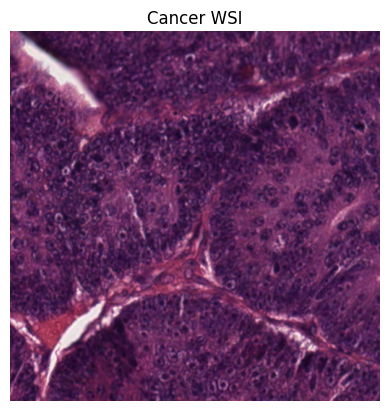

In [4]:
cancer_folder = os.path.join(DATASET_ROOT, 'TUMSTU')
image_files = [f for f in os.listdir(cancer_folder) if f.endswith('.png')]
random_image = rd.choice(image_files)
image_path = os.path.join(cancer_folder, random_image)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.title('Cancer WSI')
plt.axis('off')  # Turn off axis
plt.show()

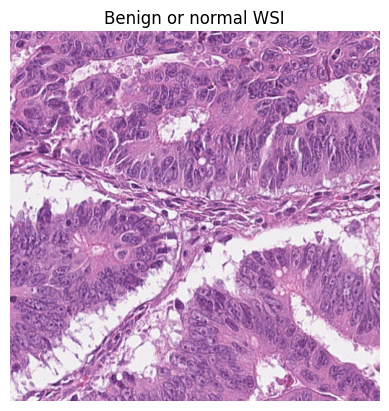

In [5]:
non_cancer_folder = os.path.join(DATASET_ROOT, 'ADIMUC_STRMUS')
image_files = [f for f in os.listdir(cancer_folder) if f.endswith('.png')]
random_image = rd.choice(image_files)
image_path = os.path.join(cancer_folder, random_image)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.title('Benign or normal WSI')
plt.axis('off')  # Turn off axis
plt.show()

In [6]:
next(iter(train_loader))

[tensor([[[[ 9.1383e-01,  8.1617e-01,  7.1851e-01,  ...,  1.2068e+00,
             1.2068e+00,  1.2068e+00],
           [ 9.1383e-01,  8.1617e-01,  7.1851e-01,  ...,  1.2068e+00,
             1.2068e+00,  1.2068e+00],
           [ 9.1383e-01,  8.1617e-01,  7.1851e-01,  ...,  1.2068e+00,
             1.2068e+00,  1.2068e+00],
           ...,
           [ 1.2068e+00,  1.2068e+00,  1.2068e+00,  ...,  1.2068e+00,
             1.2068e+00,  1.2068e+00],
           [ 1.2068e+00,  1.2068e+00,  1.2068e+00,  ...,  1.2068e+00,
             1.2068e+00,  1.2068e+00],
           [ 1.1742e+00,  1.2068e+00,  1.2068e+00,  ...,  1.2068e+00,
             1.2068e+00,  1.2068e+00]],
 
          [[ 1.5944e+00,  1.4629e+00,  1.2788e+00,  ...,  1.9364e+00,
             1.9364e+00,  1.9364e+00],
           [ 1.6207e+00,  1.4892e+00,  1.3051e+00,  ...,  1.9364e+00,
             1.9364e+00,  1.9364e+00],
           [ 1.6733e+00,  1.5155e+00,  1.3577e+00,  ...,  1.9364e+00,
             1.9364e+00,  1.9364e+00],


In [ ]:
train_counts = count_labels(train_set)
val_counts = count_labels(val_set)
test_counts = count_labels(test_set)

print("Train set: ", train_counts)
print("Val set:   ", val_counts)
print("Test set:  ", test_counts)

Train set:  {0: 2637, 1: 2637}
Val set:    {0: 806, 1: 806}
Test set:   {0: 4534, 1: 2254}


In [10]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 20, 4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p)
        self.conv2 = nn.Conv2d(20, 32, 4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(p)            # train-time and MC-dropout layer
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(self.dropout(F.relu(self.conv2(x))))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))   # dropout used here
        x = self.fc2(x)
        return x


# Initialize the model
cnn = SmallCNN().to(device)

In [11]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)

# Training Loop
num_epochs = 1
for epoch in range(num_epochs):
    cnn.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate cnn at the end of current epoch
    cnn.eval()
    correct = 0
    total = 0
    print('TESTING')
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(cnn.state_dict(), "C:/Users/ejeme/Documents/python_repos/WSI_histo/cnn_wsi_binary_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 352/352 [00:36<00:00,  9.75it/s]


Epoch [1/1], Loss: 0.3471
Train Accuracy: 85.38%
TESTING
Validation Accuracy: 89.33%


### Retrieving Softmax Response, Predicted class and True class for all samples in val and test sets

In [24]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/ejeme/Documents/python_repos/WSI_histo/cnn_wsi_binary_epoch0.pth")
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [ ]:
sgp_dico_test = prepare_sgp_dico(test_loader, model = cnn, device = device, T = 1)
sgp_set = pd.DataFrame(sgp_dico_test)

100%|██████████| 453/453 [00:41<00:00, 10.91it/s]


In [ ]:
sgp_set.sort_values('kappa')

,y_true,y_pred,kappa
5702,0.0,0.0,0.500379
3593,0.0,1.0,0.500489
3058,0.0,1.0,0.500583
4491,0.0,1.0,0.500759
3089,0.0,1.0,0.500917
...,...,...,...
4730,0.0,0.0,0.998383
6386,0.0,0.0,0.998391
2105,0.0,0.0,0.998405
4012,0.0,0.0,0.998439


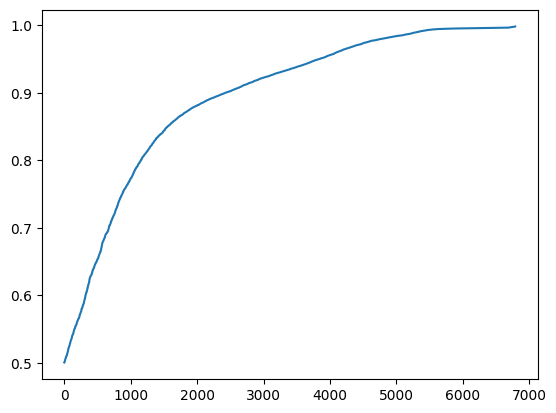

In [ ]:
plt.plot(list(sgp_set.sort_values('kappa').kappa))
plt.show()

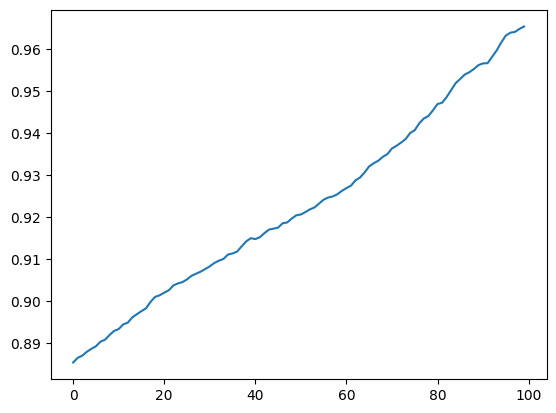

In [ ]:
accs=[]
for theta in np.linspace(0.5,0.9,num=100):
    selected = sgp_set.loc[sgp_set.kappa >= theta].copy()
    accs.append((selected.y_true==selected.y_pred).sum()/selected.shape[0])
plt.plot(accs)
plt.show()

In [ ]:
pickle.dump(sgp_set, open('sgp_set_cnn','wb'))

### Retrieving MC dropout binary entropy, Predicted class and True class for all samples in CNN test set 

In [ ]:
sgp_set = pickle.load(open('sgp_set_cnn', 'rb'))

In [22]:
y_pred_det, mean_p, var_p = mc_var_for_deployed_class(cnn, test_loader, device, T=30)

Deterministic pass: 100%|██████████| 453/453 [00:41<00:00, 10.83it/s]


In [ ]:
sgp_set['kappa'] = -var_p.numpy()

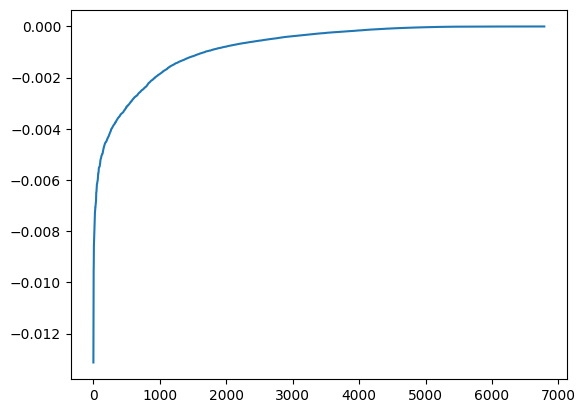

In [ ]:
plt.plot(list(sgp_set.sort_values('kappa').kappa))

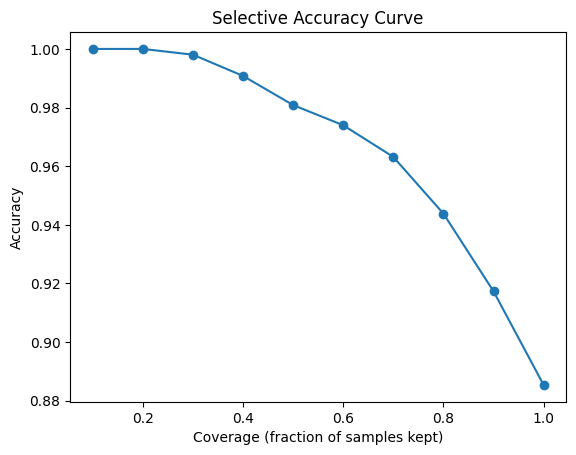

In [ ]:
y_true = torch.tensor(sgp_set.y_true)
cover, acc = selective_accuracy(-var_p, y_pred_det, y_true)
plt.plot(cover, acc, marker="o")
plt.xlabel("Coverage (fraction of samples kept)")
plt.ylabel("Accuracy")
plt.title("Selective Accuracy Curve")
plt.show()

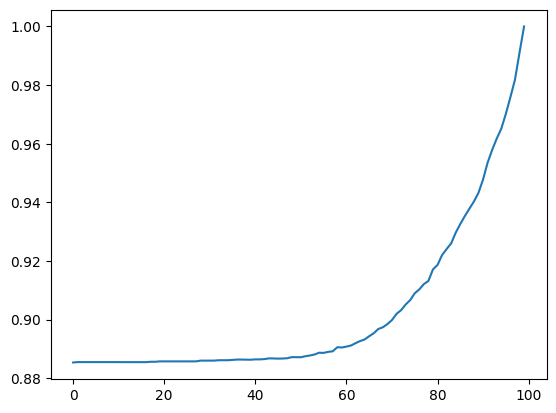

In [ ]:
accs = []
for t in np.linspace(sgp_set.kappa.min(), sgp_set.kappa.max(), num = 100):
    selected = sgp_set.loc[sgp_set.kappa >= t].copy()
    accs.append((selected.y_true==selected.y_pred).sum()/selected.shape[0])
plt.plot(accs)
plt.show()

In [ ]:
pickle.dump(sgp_set.reset_index(drop=True), open('sgp_set_cnn_MCD','wb'))